In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use("default")
sns.set_context("notebook")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
df = pd.read_csv("D:\DataScience\Data\CustomerChurn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\CM\AppData\Local\Temp\ipykernel_6480\699720824.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\DataScience\Data\CustomerChurn\WA_Fn-UseC_-Telco-Customer-Churn.csv")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape

(7043, 21)

In [5]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percent.round(2)
})

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


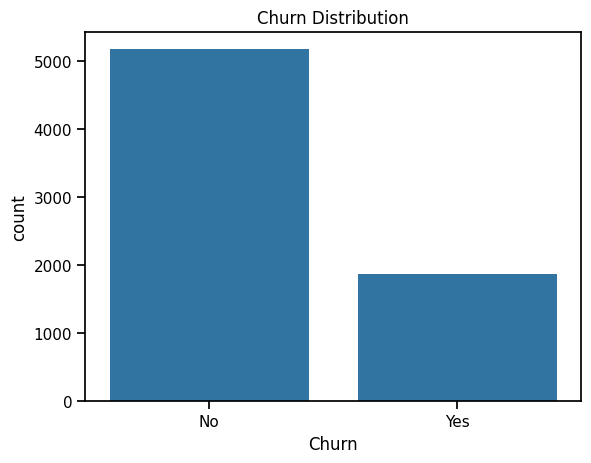

In [6]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

In [7]:
#Feature grouping
demographic_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents"
]

service_features = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

account_features = [
    "tenure", "Contract", "PaperlessBilling", "PaymentMethod"
]

billing_features = [
    "MonthlyCharges", "TotalCharges"
]

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

In [10]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [11]:
df[["TotalCharges"]].describe()


,TotalCharges
count,7043
unique,6531
top,20.2
freq,11


In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

EDA

In [13]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


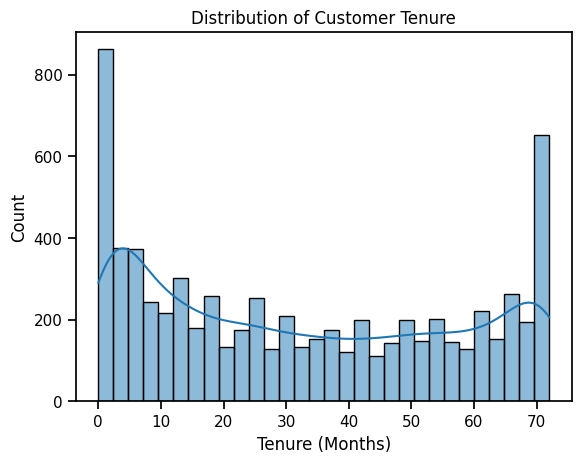

In [14]:
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.show()

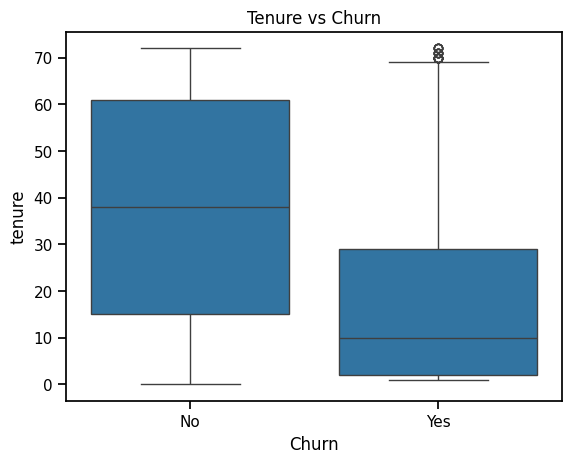

In [15]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

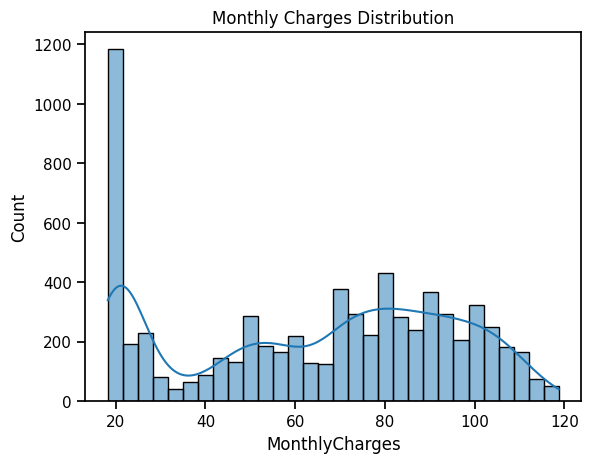

In [16]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

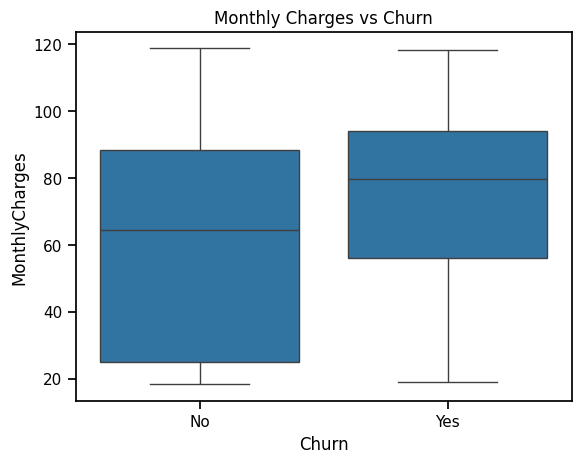

In [17]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

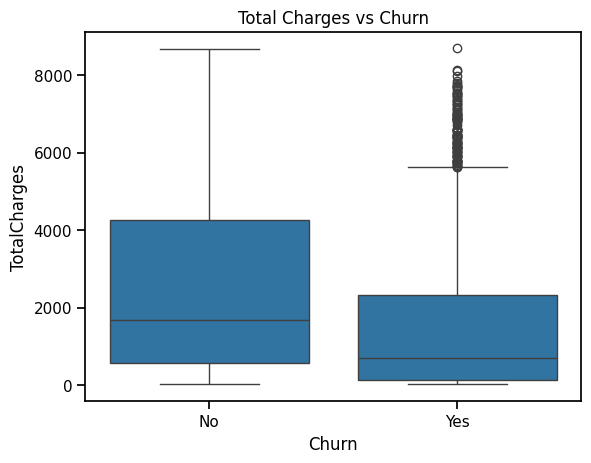

In [18]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges vs Churn")
plt.show()

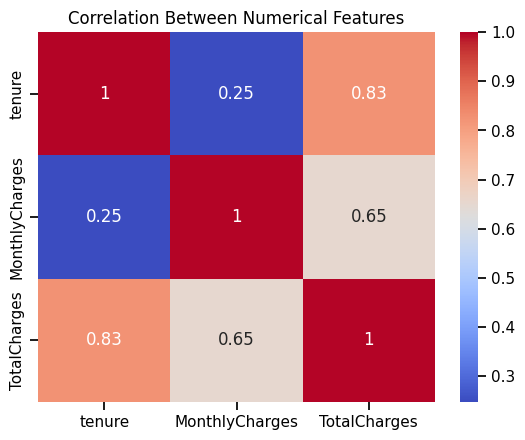

In [19]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[num_features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Features")
plt.show()

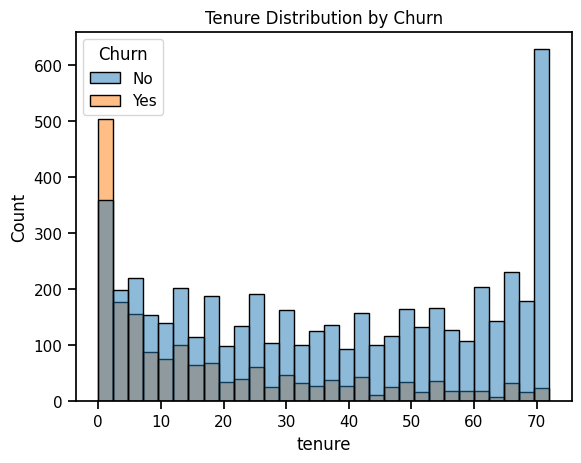

In [20]:
plt.figure()
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=False)
plt.title("Tenure Distribution by Churn")
plt.show()

In [21]:
def churn_rate_by_feature(df, feature):
    churn_table = (
        df.groupby(feature)["Churn"]
        .value_counts(normalize=True)
        .rename("rate")
        .reset_index()
    )
    return churn_table[churn_table["Churn"] == "Yes"].sort_values("rate", ascending=False)

In [22]:
churn_rate_by_feature(df, "Contract")

,Contract,Churn,rate
1,Month-to-month,Yes,0.427097
3,One year,Yes,0.112695
5,Two year,Yes,0.028319


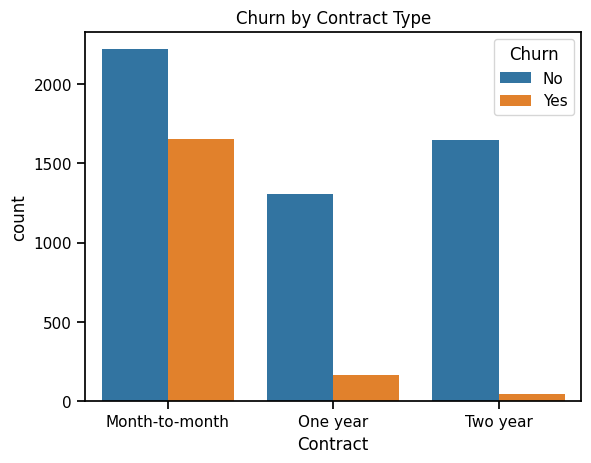

In [23]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

In [24]:
churn_rate_by_feature(df, "InternetService")

,InternetService,Churn,rate
3,Fiber optic,Yes,0.418928
1,DSL,Yes,0.189591
5,No,Yes,0.074050


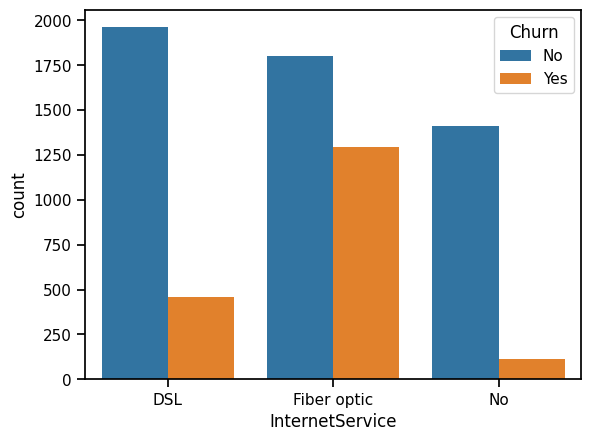

In [25]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.show()

In [26]:
churn_rate_by_feature(df, "PaymentMethod")

,PaymentMethod,Churn,rate
5,Electronic check,Yes,0.452854
7,Mailed check,Yes,0.191067
1,Bank transfer (automatic),Yes,0.167098
3,Credit card (automatic),Yes,0.152431


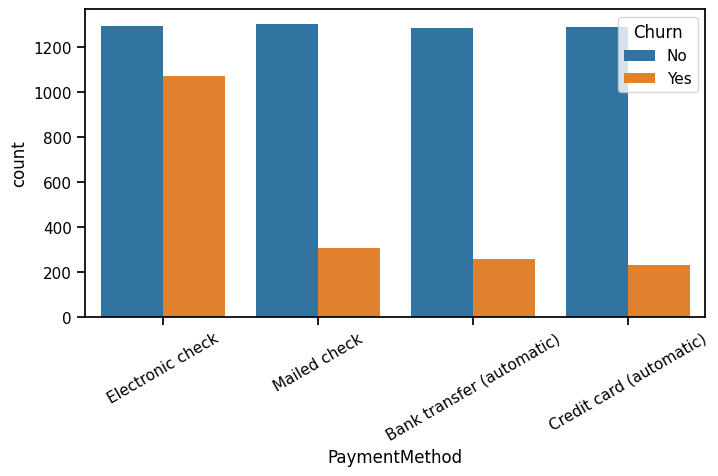

In [27]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=30)
plt.show()

In [28]:
churn_rate_by_feature(df, "TechSupport")

,TechSupport,Churn,rate
1,No,Yes,0.416355
5,Yes,Yes,0.151663
3,No internet service,Yes,0.074050


In [29]:
churn_rate_by_feature(df, "OnlineSecurity")

,OnlineSecurity,Churn,rate
1,No,Yes,0.417667
5,Yes,Yes,0.146112
3,No internet service,Yes,0.074050


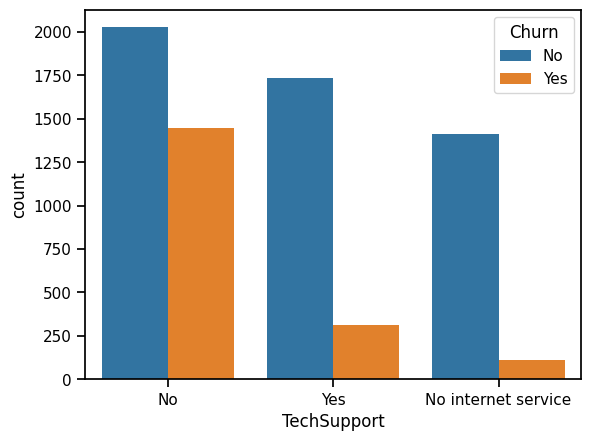

In [30]:
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.show()

In [31]:
churn_rate_by_feature(df, "SeniorCitizen")

,SeniorCitizen,Churn,rate
3,1,Yes,0.416813
1,0,Yes,0.236062


In [32]:
churn_rate_by_feature(df, "Partner")
churn_rate_by_feature(df, "Dependents")

,Dependents,Churn,rate
1,No,Yes,0.312791
3,Yes,Yes,0.154502
